# 02 — Target Definition, Feature Engineering, and a Tree-Based Targeting Model

This notebook builds a household-level targeting model for off-grid solar outreach in North-West Nigeria, using the MTF survey ingested in notebook `01`.

**Design decisions, documented up front:**
- **Target:** willingness to pay upfront for a solar device at a randomly offered price (survey item `E_3`; 29% positive). Current solar ownership was rejected as a target — at 1.2% prevalence it is severely imbalanced and mismatched with the business question (see notebook `01`).
- **The offered price is a feature, not noise:** the survey embedded a randomized willingness-to-pay experiment, assigning each household a random price. `E_3` therefore means *willing at the offered price*, and the price variable carries experimentally grounded signal.
- **Evaluation metric:** precision among the top 20% of model-ranked households — matching the deployment decision ("which fifth of households should a vendor contact?") rather than accuracy at an arbitrary 0.5 threshold.

## Setup

In [1]:
import pandas as pd
from pathlib import Path

DATA = Path("../raw_data/extracted/TO UPLOAD")
print("Ready.")

Ready.


## Target construction

From Section E we retain the household key, the willingness-to-pay response, and the randomly offered price. Households never asked the question are dropped; the survey's "don't know" code (888) is excluded by restricting the target to {0, 1}.

In [2]:
sec_e = pd.read_stata(DATA / "MTF_NG_HH_SEC_E.dta", convert_categoricals=False)

target_df = sec_e[["HH_ID", "E_3", "solar_price"]].copy()
target_df = target_df[target_df["E_3"].isin([0, 1])]
target_df = target_df.rename(columns={"E_3": "willing_to_pay"})

print("Households with a usable target:", len(target_df))
print(target_df["willing_to_pay"].value_counts(normalize=True).round(3))

Households with a usable target: 3625
willing_to_pay
0.0    0.71
1.0    0.29
Name: proportion, dtype: float64


## Locational features

Urban/rural classification from the household identification file.

In [3]:
ident = pd.read_stata(DATA / "MTF_NG_HH_Identification.dta", convert_categoricals=False)
print(ident["Urbanization"].value_counts(dropna=False))

Urbanization
2.0    1835
1.0    1833
NaN       1
Name: count, dtype: int64


## Merging survey sections

`HH_ID` is the household's unique key across all section files. Every merge below is followed by a row-count check: the household-level dataframe must remain at 3,625 rows. A growing row count would indicate a one-to-many join against a person-level file — silent corruption of the unit of analysis.

In [4]:
df = target_df.merge(ident[["HH_ID", "Urbanization", "state_id"]], on="HH_ID", how="left")
print("Shape after merge:", df.shape)
df.head()

Shape after merge: (3625, 5)


,HH_ID,willing_to_pay,solar_price,Urbanization,state_id
0,1.000506e+12,0.0,33000.0,1.0,6.0
1,1.000506e+12,1.0,2970.0,1.0,6.0
2,1.000506e+12,0.0,2970.0,1.0,6.0
3,1.000506e+12,1.0,2970.0,1.0,6.0
4,1.000506e+12,0.0,9000.0,1.0,6.0


## Locating predictors in the codebook

Candidate predictors were selected on theoretical grounds (residence, household economic status, education of household head, financial inclusion) and located in the survey via a variable-label search across section files. Notes from that search:

- Direct household income is not measured — standard for surveys of largely informal economies, where consumption expenditure (Section L) is the accepted proxy.
- Head's education lives in the person-level roster (`A9` in `SEC_A1`), requiring a filter to household heads before merging.
- Financial-inclusion indicators (formal bank account `B16`, mobile money `B21`) live in Section B.

In [5]:
def search_labels(filename, keyword):
    """Search a .dta file's variable labels for a keyword."""
    with pd.io.stata.StataReader(DATA / filename) as reader:
        labels = reader.variable_labels()
    for var, label in labels.items():
        if keyword.lower() in str(label).lower():
            print(f"{var:20s} | {str(label)[:70]}")

search_labels("MTF_NG_HH_SEC_B.dta", "phone")

B22                  | B22. Do you use mobile money to make payments over the mobile phone?




In [6]:
search_labels("MTF_NG_HH_SEC_A1.dta", "education")
search_labels("MTF_NG_HH_SEC_B.dta", "income")
search_labels("MTF_NG_HH_SEC_L.dta", "expend")
search_labels("MTF_NG_HH_SEC_L.dta", "total")

A9                   | What is the highest education level you have completed?


In [7]:
with pd.io.stata.StataReader(DATA / "MTF_NG_HH_SEC_A1.dta") as r:
    print(r.value_labels()["A9"])

{np.int32(0): 'NONE', np.int32(1): 'N1', np.int32(2): 'N2', np.int32(11): 'P1', np.int32(12): 'P2', np.int32(13): 'P3', np.int32(14): 'P4', np.int32(15): 'P5', np.int32(16): 'P6', np.int32(21): 'JS1', np.int32(22): 'JS2', np.int32(23): 'JS3', np.int32(24): 'SS1', np.int32(25): 'SS2', np.int32(26): 'SS3', np.int32(27): 'LOWER 6', np.int32(28): 'UPPER 6', np.int32(31): 'TEACHER TRAINING', np.int32(32): 'VOCATIONAL/TECHNICAL', np.int32(33): 'MODERNSCHOOL', np.int32(34): 'NCE', np.int32(41): 'POLY/PROF', np.int32(42): '1ST DEGREE', np.int32(43): 'HIGHER DEGREE', np.int32(51): 'QUARANIC', np.int32(52): 'INTEGRATED QUARANIC', np.int32(61): 'ADULT EDUCATION'}


## Feature engineering

**Education requires culturally honest recoding.** The `A9` codes include Quranic schooling (code 51) — the single most common category in this Northern sample — which is not a rung on the formal-education ladder. Forcing it into an ordered scale would be sociologically false. It is therefore modeled as two variables: an ordered formal-education band (0 none / 1 primary / 2 secondary / 3 post-secondary) and a separate Quranic-education indicator. Integrated Quranic schools (code 52), which teach the national curriculum, are counted as primary.

Urban/rural is encoded as a single named binary. Cryptic survey variable names are renamed at the merge (`B16` → `bank_account`, `B21` → `mobile_money`) so the feature matrix is self-documenting.

In [8]:
a1 = pd.read_stata(DATA / "MTF_NG_HH_SEC_A1.dta", convert_categoricals=False)
print(a1.shape)                          # person-level roster, not households
print(a1["A4"].value_counts().head())    # code 1 = household head (3,669 = one per household)

heads = a1[a1["A4"] == 1][["HH_ID", "A9"]].copy()

def formal_band(code):
    if code in (11,12,13,14,15,16,52):        # primary (incl. integrated Quranic)
        return 1
    if code in (21,22,23,24,25,26,27,28):     # junior/senior secondary
        return 2
    if code in (31,32,33,34,41,42,43):        # post-secondary
        return 3
    return 0                                   # none, nursery, Quranic-only, adult ed

heads["head_edu_band"] = heads["A9"].apply(formal_band)
heads["head_quranic"] = heads["A9"].isin([51, 52]).astype(int)

df = df.merge(heads[["HH_ID", "head_edu_band", "head_quranic"]], on="HH_ID", how="left")
print(df.shape)    # must remain 3,625 rows

df["urban"] = (df["Urbanization"] == 2).astype(int)

(22597, 19)
A4
3    13715
2     4206
1     3669
4      348
7      197
Name: count, dtype: int64
(3625, 7)


In [9]:
# Grid connection (Section E), financial inclusion (Section B), household size (roster)
grid = sec_e[["HH_ID", "E1"]].rename(columns={"E1": "grid_connected"})
df = df.merge(grid, on="HH_ID", how="left")

sec_b = pd.read_stata(DATA / "MTF_NG_HH_SEC_B.dta", convert_categoricals=False)
df = df.merge(sec_b[["HH_ID", "B16", "B21"]].rename(
    columns={"B16": "bank_account", "B21": "mobile_money"}), on="HH_ID", how="left")

hh_size = a1.groupby("HH_ID").size().reset_index(name="hh_size")
df = df.merge(hh_size, on="HH_ID", how="left")

print(df.shape)   # must remain 3,625 rows

(3625, 12)


In [10]:
print(df["bank_account"].value_counts(dropna=False))
print(df["mobile_money"].value_counts(dropna=False))

bank_account
0.0    2640
1.0     985
Name: count, dtype: int64
mobile_money
0.0    3542
1.0      83
Name: count, dtype: int64


In [11]:
features = ["solar_price", "urban", "head_edu_band", "head_quranic",
            "grid_connected", "hh_size", "bank_account", "mobile_money"]
X = df[features].fillna(df[features].median())
y = df["willing_to_pay"]

## Model training

An 80/20 stratified split preserves the 71/29 class balance in both partitions. The initial tree is limited to `max_depth=3` as an overfitting guard; model complexity is examined systematically below.

In [12]:
from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeClassifier

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y)

tree = DecisionTreeClassifier(max_depth=3, random_state=42)
tree.fit(X_train, y_train)
print("Tree grown.")

Tree grown.


## Inspecting the fitted tree

Each node reports its splitting rule, Gini impurity, sample count, and class counts (`value = [not willing, willing]`). Left branches correspond to the split condition being true.

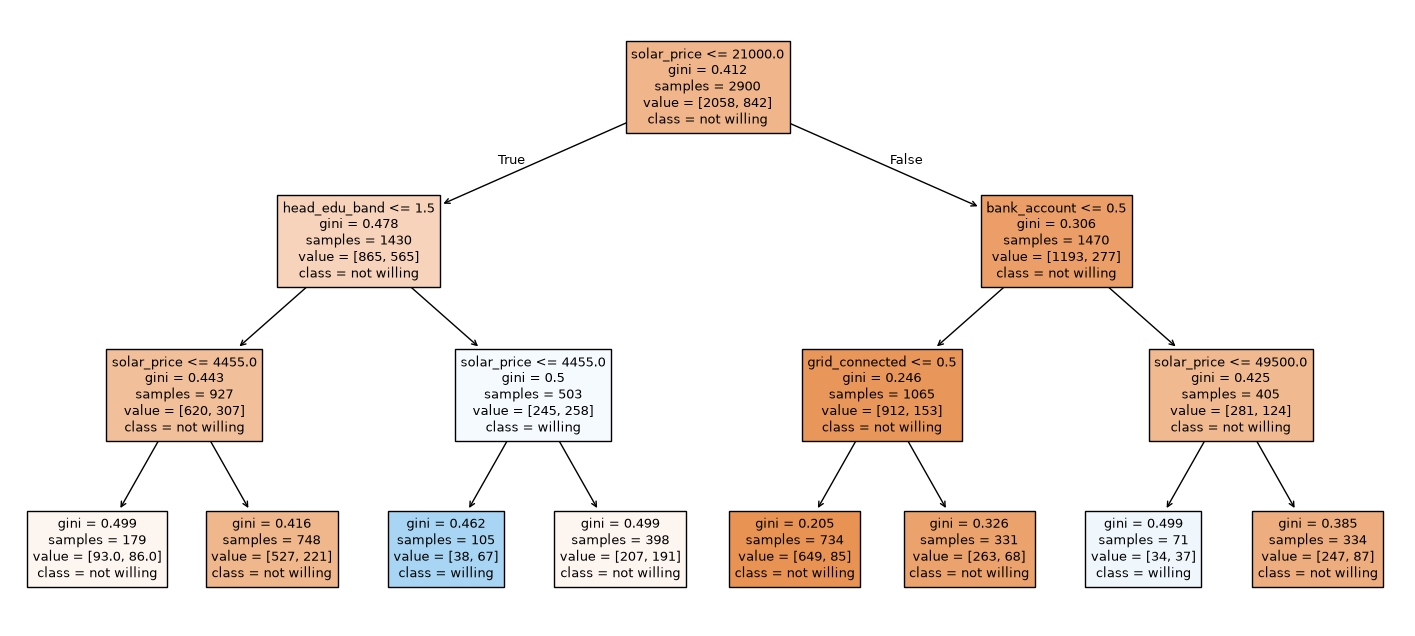

In [13]:
import matplotlib.pyplot as plt
from sklearn.tree import plot_tree

plt.figure(figsize=(18, 8))
plot_tree(tree, feature_names=X.columns, class_names=["not willing", "willing"],
          filled=True, fontsize=9)
plt.show()

## Interpreting the model

The randomly assigned **price takes the root split** (≤ ₦21,000) — consistent with the embedded willingness-to-pay experiment, which guarantees price exogenous variation. Household head's **education band** and **formal bank account ownership** provide the next-strongest signal. Urban residence contributes no additional splitting power once price and education are accounted for.

The purest leaf (Gini 0.219) holds 608 households — 87.5% unwilling — characterized by lower offered prices but low education: an affordable price alone does not convert households without the socioeconomic profile to act on it.

## Evaluation against baseline

The majority-class baseline (predicting "not willing" for all) achieves 71% accuracy. Performance is therefore judged by improvement over that baseline and, ultimately, by ranking quality in the business metric below.

In [14]:
from sklearn.metrics import accuracy_score, classification_report

y_pred = tree.predict(X_test)
print("Baseline (majority class): 0.71")
print("Tree accuracy:", round(accuracy_score(y_test, y_pred), 3))
print(classification_report(y_test, y_pred, target_names=["not willing", "willing"]))

Baseline (majority class): 0.71
Tree accuracy: 0.724
              precision    recall  f1-score   support

 not willing       0.73      0.96      0.83       515
     willing       0.60      0.14      0.22       210

    accuracy                           0.72       725
   macro avg       0.67      0.55      0.53       725
weighted avg       0.70      0.72      0.66       725



In [15]:
for name, imp in zip(X.columns, tree.feature_importances_):
    print(f"{name:20s} {imp:.3f}")

solar_price          0.673
urban                0.000
head_edu_band        0.173
head_quranic         0.000
grid_connected       0.029
hh_size              0.000
bank_account         0.124
mobile_money         0.000


In [16]:
print("train:", round(tree.score(X_train, y_train), 3))
print("test: ", round(tree.score(X_test, y_test), 3))

train: 0.721
test:  0.724


## Model complexity: the underfitting–overfitting transition

Sweeping `max_depth` from 1 to 12 traces the classic pattern: training and test scores move together while the model is too simple, then diverge — training accuracy climbing while test accuracy decays — once the tree begins memorizing training households (from depth ≈ 7).

In [17]:
for depth in range(1, 13):
    t = DecisionTreeClassifier(max_depth=depth, random_state=42).fit(X_train, y_train)
    print(f"depth {depth:2d}   train {t.score(X_train, y_train):.3f}   test {t.score(X_test, y_test):.3f}")

depth  1   train 0.710   test 0.710
depth  2   train 0.714   test 0.741
depth  3   train 0.721   test 0.724
depth  4   train 0.733   test 0.737
depth  5   train 0.737   test 0.731
depth  6   train 0.747   test 0.732
depth  7   train 0.762   test 0.719
depth  8   train 0.777   test 0.720
depth  9   train 0.791   test 0.714
depth 10   train 0.802   test 0.705
depth 11   train 0.812   test 0.677
depth 12   train 0.824   test 0.681


## Cross-validated tuning

Hyperparameters are selected by 5-fold cross-validation *within the training set*, keeping the test set untouched as a final evaluation. Scoring uses ROC-AUC — ranking quality — because deployment is a ranking task. `min_samples_leaf` guards against small, statistically unreliable leaves.

In [18]:
from sklearn.model_selection import GridSearchCV

grid = GridSearchCV(
    DecisionTreeClassifier(random_state=42),
    param_grid={"max_depth": range(1, 13), "min_samples_leaf": [1, 10, 25, 50]},
    cv=5, scoring="roc_auc")
grid.fit(X_train, y_train)

print("Best parameters:", grid.best_params_)
best_tree = grid.best_estimator_
print("Test accuracy:", round(best_tree.score(X_test, y_test), 3))

Best parameters: {'max_depth': 5, 'min_samples_leaf': 50}
Test accuracy: 0.731


## Business evaluation: precision at the top 20%

The deployment question is not "is each prediction right at a 0.5 cutoff?" but "if the vendor contacts the 20% of households the model ranks highest, how many convert?" Households are ranked by predicted probability and the top fifth is compared against the random-targeting baseline.

In [19]:
import numpy as np

probs = best_tree.predict_proba(X_test)[:, 1]
k = int(0.20 * len(X_test))
top_idx = np.argsort(probs)[::-1][:k]

precision_at_20 = y_test.iloc[top_idx].mean()
print(f"Top-20% contact list: {k} households")
print("Precision at top 20%:", round(precision_at_20, 3))
print("Random-targeting baseline:", round(y_test.mean(), 3))
print("Lift over random:", round(precision_at_20 / y_test.mean(), 2), "x")

Top-20% contact list: 145 households
Precision at top 20%: 0.579
Random-targeting baseline: 0.29
Lift over random: 2.0 x


## Conclusion

A cross-validated decision tree (`max_depth=5`, `min_samples_leaf=50`) ranks households such that the **top-20% contact list converts at 57.9%, against a 29% random-targeting baseline — a 2.0× lift** in outreach productivity.

**Next steps:** ensemble methods (random forest, gradient boosting) evaluated on the same precision-at-top-20 metric; fairness diagnostics across gender and urban/rural segments; a client-facing targeting brief.